In [21]:
import pandas as pd
df=pd.read_csv('simulated_agent_5k.csv')
print(df.head())

   Trial  Block Conflict Trial_Type  Cue_Valence  Optimal_Action  \
0      1  B1_MC       PC        NAL           -1               0   
1      2  B1_MC       PI         NW            1               0   
2      3  B1_MC       PI         NW            1               0   
3      4  B1_MC       PC         GW            1               1   
4      5  B1_MC       PC         GW            1               1   

   Agent_Choice  Agent_Reward  Correct  
0           1.0          -1.0        0  
1           0.0           1.0        1  
2           0.0           1.0        1  
3           0.0           0.0        0  
4           1.0           1.0        1  


In [22]:
## DIRECT INFERENCE
# print(df)
def direct_inference(df,length):
    results=[]
    for i in range(0,len(df),length):
        window=df.iloc[i:i+length]
        # get pc and pi for the specified widow
        pc_trials=window[window['Conflict'] == 'PC']
        pc_acc=pc_trials['Correct'].mean()
        pi_trials=window[window['Conflict'] == 'PI']
        pi_acc=pi_trials['Correct'].mean()
        pcpi_diff= pc_acc-pi_acc
        inference=str()
        # inferring
        if pcpi_diff > 0.7:
            inference='Low conflict'
        elif pcpi_diff < 0.3:
            inference='High conflict'
        else:
            inference='Med conflict'
        results.append({
            'start':i,
            'end' :i+length,
            'pc-pi diff':pcpi_diff,
            'pc_acc':pc_acc,
            'pi_acc':pi_acc,
            'inference': inference,
            'true_block': window['Block'].iloc[0]
        })
    return pd.DataFrame(results)

x=direct_inference(df,125)
print(f"{x.head()}")

   start  end  pc-pi diff    pc_acc    pi_acc      inference true_block
0      0  125    0.214700  0.849315  0.634615  High conflict      B1_MC
1    125  250    0.284591  0.867925  0.583333  High conflict      B1_MC
2    250  375    0.113672  0.878378  0.764706  High conflict      B1_MC
3    375  500    0.275474  0.920635  0.645161  High conflict      B1_MC
4    500  625    0.153251  0.947368  0.794118  High conflict      B1_MC


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

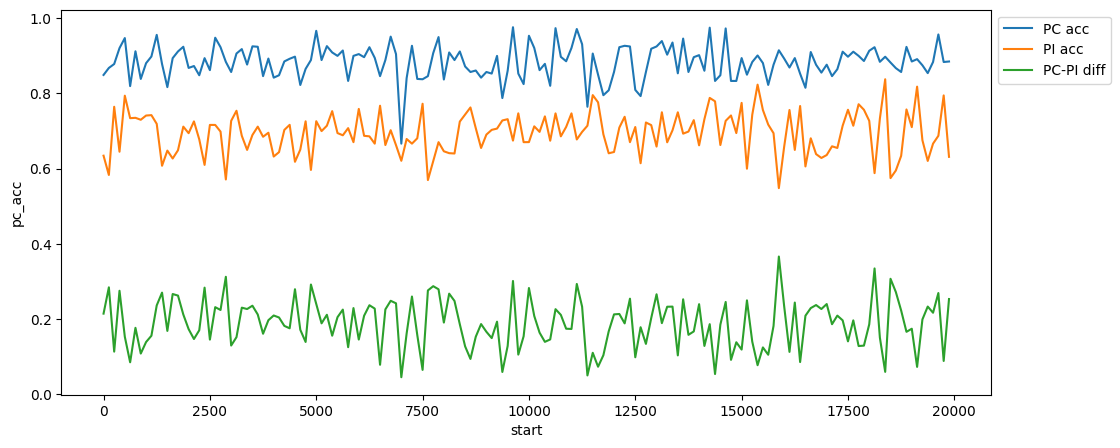

<Figure size 640x480 with 0 Axes>

In [24]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=x, x='start', y='pc_acc', label='PC acc')
sns.lineplot(data=x, x='start', y='pi_acc', label='PI acc')
sns.lineplot(data=x, x='start', y='pc-pi diff', label='PC-PI diff')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()
plt.savefig('accuracy_trends.png', dpi=150, bbox_inches='tight')

Well, splitting trials into chunks and taking accuracy didn't give any meaningful results.

In [25]:

# 1. Ensure the columns are integers
df['Agent_Choice'] = df['Agent_Choice'].astype(int)
df['Agent_Reward'] = df['Agent_Reward'].astype(int)

# 2. Explicitly hardcode every combination using .loc
# Format: df.loc[(Condition 1) & (Condition 2), 'New_Column_Name'] = Value

df.loc[(df['Agent_Choice'] == 0) & (df['Agent_Reward'] == -1), 'obs'] = 0
df.loc[(df['Agent_Choice'] == 0) & (df['Agent_Reward'] ==  0), 'obs'] = 1
df.loc[(df['Agent_Choice'] == 0) & (df['Agent_Reward'] ==  1), 'obs'] = 2

df.loc[(df['Agent_Choice'] == 1) & (df['Agent_Reward'] == -1), 'obs'] = 3
df.loc[(df['Agent_Choice'] == 1) & (df['Agent_Reward'] ==  0), 'obs'] = 4
df.loc[(df['Agent_Choice'] == 1) & (df['Agent_Reward'] ==  1), 'obs'] = 5

print(df[['Agent_Choice', 'Agent_Reward', 'obs']].head(10))

   Agent_Choice  Agent_Reward  obs
0             1            -1  3.0
1             0             1  2.0
2             0             1  2.0
3             0             0  1.0
4             1             1  5.0
5             1             1  5.0
6             0             0  1.0
7             1            -1  3.0
8             1            -1  3.0
9             0             0  1.0


In [28]:
from hmmlearn import hmm
import numpy as np

# Force the values to be integers before reshaping
obs_seq = df['obs'].astype(int).values.reshape(-1, 1)

# fit HMM with 3 hidden states
model = hmm.CategoricalHMM(n_components=3, n_iter=100, random_state=42)
model.fit(obs_seq)

,n_components,3
,n_features,np.int64(6)
,random_state,RandomState(M...0x7EFC6EC41E40
,n_iter,100
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,algorithm,'viterbi'
,tol,0.01
,verbose,False
,params,'ste'


In [30]:
import pandas as pd

# 1. Decode the sequence to get the raw state predictions (0, 1, or 2)
df['hmm_state'] = model.predict(obs_seq)

# 2. Hardcode the TRUE labels based on trial numbers (row index)
df['true_label'] = 'Unknown'
df.loc[(df.index >= 0) & (df.index < 5000), 'true_label'] = 'MC'
df.loc[(df.index >= 5000) & (df.index < 15000), 'true_label'] = 'HC'
df.loc[(df.index >= 15000), 'true_label'] = 'LC'

# 3. Print the raw Crosstab (Confusion Matrix)
print("Confusion Matrix (True Block vs Raw HMM State)")
conf_df = pd.crosstab(
    df['true_label'], 
    df['hmm_state'], 
    rownames=['True Block'], 
    colnames=['HMM Output']
)

# Ensure rows are ordered logically
conf_df = conf_df.reindex(['LC', 'MC', 'HC'])

# Rename the columns to explicitly say "State 0", "State 1", etc.
conf_df.columns = [f'State {col}' for col in conf_df.columns]

print(conf_df)

Confusion Matrix (True Block vs Raw HMM State)
            State 0  State 1  State 2
True Block                           
LC             2498     2501        1
MC             1437     1438     2125
HC                0        0    10000


In [31]:
print("Transition matrix:")
print(model.transmat_.round(3))

print("\nEmission probabilities:")
print(model.emissionprob_.round(3))

print("\nInitial state probabilities:")
print(model.startprob_.round(3))

hidden_states = model.predict(obs_seq)
df['hmm_state'] = hidden_states
print(df.groupby(['Block', 'hmm_state']).size().unstack(fill_value=0))

Transition matrix:
[[0.003 0.997 0.   ]
 [0.976 0.021 0.003]
 [0.001 0.    0.999]]

Emission probabilities:
[[0.026 0.303 0.084 0.066 0.241 0.281]
 [0.028 0.268 0.102 0.045 0.236 0.322]
 [0.047 0.141 0.184 0.028 0.45  0.15 ]]

Initial state probabilities:
[1. 0. 0.]
hmm_state     0     1     2
Block                      
B1_MC      1437  1438  2125
B2_HC1        0     0  5000
B3_HC2        0     0  5000
B4_LC      2498  2501     1


In [32]:
#observations and their cue-reward association
# Extract the unique combinations of Observation, Choice, and Reward directly from the dataframe
mapping_df = df[['obs', 'Agent_Choice', 'Agent_Reward']].drop_duplicates().sort_values('obs')

# Generate the labels dynamically using list comprehension
obs_labels = [
    f"Ch:{int(row['Agent_Choice'])}\nRw:{int(row['Agent_Reward'])}" 
    for _, row in mapping_df.iterrows()
]
# Verify what the code just generated from your data
print(obs_labels)
'''
obs0 = Ng & -1
obs1 = Ng & 0
obs2 = Ng & +1
obs3 = G & -1
obs4 = G & 0
obs5 = G & 1
'''

['Ch:0\nRw:-1', 'Ch:0\nRw:0', 'Ch:0\nRw:1', 'Ch:1\nRw:-1', 'Ch:1\nRw:0', 'Ch:1\nRw:1']


'\nobs0 = Ng & -1\nobs1 = Ng & 0\nobs2 = Ng & +1\nobs3 = G & -1\nobs4 = G & 0\nobs5 = G & 1\n'

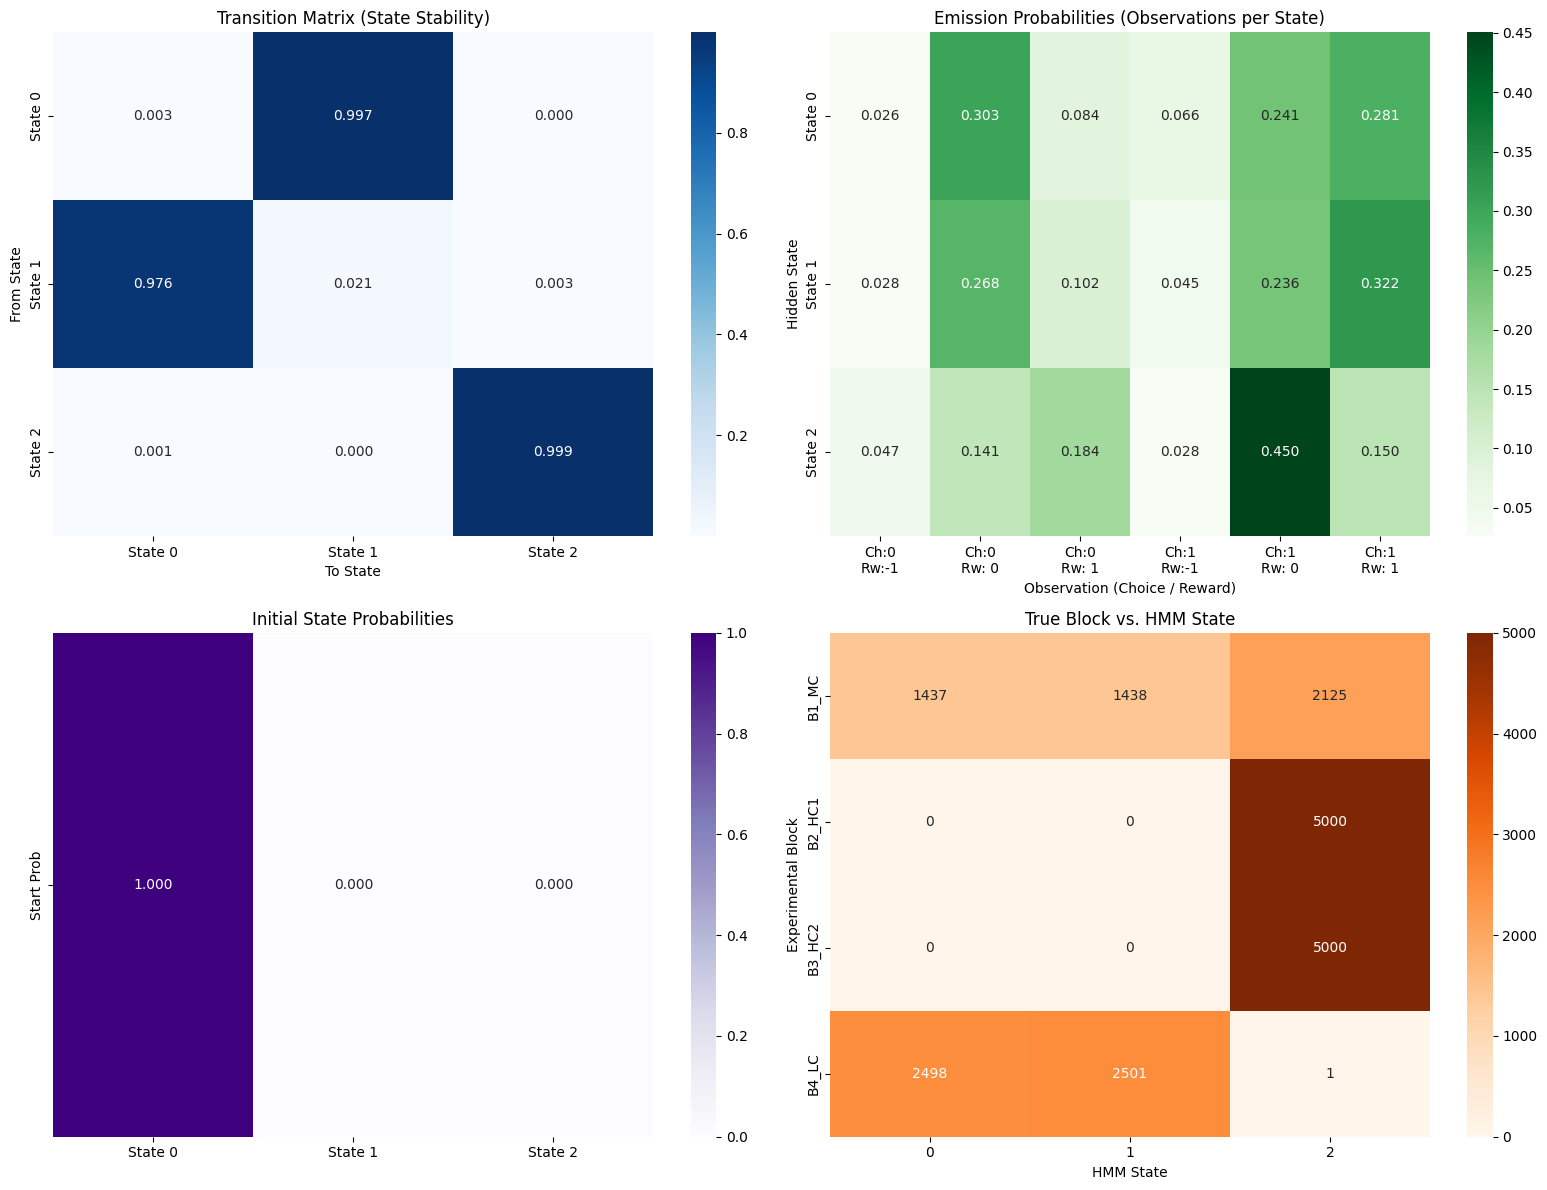

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Generate the state predictions and crosstab dataframe
hidden_states = model.predict(obs_seq)
df['hmm_state'] = hidden_states
crosstab_df = df.groupby(['Block', 'hmm_state']).size().unstack(fill_value=0)

# 2. Define the meaningful labels for your 6 observations
# Ch = Choice, Rw = Reward

obs_labels = [
    'Ch:0\nRw:-1',  # Obs 0
    'Ch:0\nRw: 0',  # Obs 1
    'Ch:0\nRw: 1',  # Obs 2
    'Ch:1\nRw:-1',  # Obs 3
    'Ch:1\nRw: 0',  # Obs 4
    'Ch:1\nRw: 1'   # Obs 5
]

# 3. Set up a 2x2 grid for the heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot A: Transition Matrix ---
sns.heatmap(model.transmat_, annot=True, cmap='Blues', fmt='.3f', ax=axes[0, 0],
            xticklabels=['State 0', 'State 1', 'State 2'],
            yticklabels=['State 0', 'State 1', 'State 2'])
axes[0, 0].set_title('Transition Matrix (State Stability)')
axes[0, 0].set_xlabel('To State')
axes[0, 0].set_ylabel('From State')

# --- Plot B: Emission Probabilities ---
# Use the custom obs_labels list here
sns.heatmap(model.emissionprob_, annot=True, cmap='Greens', fmt='.3f', ax=axes[0, 1],
            yticklabels=['State 0', 'State 1', 'State 2'],
            xticklabels=obs_labels)
axes[0, 1].set_title('Emission Probabilities (Observations per State)')
axes[0, 1].set_xlabel('Observation (Choice / Reward)')
axes[0, 1].set_ylabel('Hidden State')

# --- Plot C: Initial State Probabilities ---
sns.heatmap(model.startprob_.reshape(1, -1), annot=True, cmap='Purples', fmt='.3f', ax=axes[1, 0],
            xticklabels=['State 0', 'State 1', 'State 2'],
            yticklabels=['Start Prob'])
axes[1, 0].set_title('Initial State Probabilities')

# --- Plot D: True Block vs. HMM State (Crosstab) ---
sns.heatmap(crosstab_df, annot=True, cmap='Oranges', fmt='d', ax=axes[1, 1])
axes[1, 1].set_title('True Block vs. HMM State')
axes[1, 1].set_xlabel('HMM State')
axes[1, 1].set_ylabel('Experimental Block')

# 4. Adjust layout and display
plt.tight_layout()
plt.show()

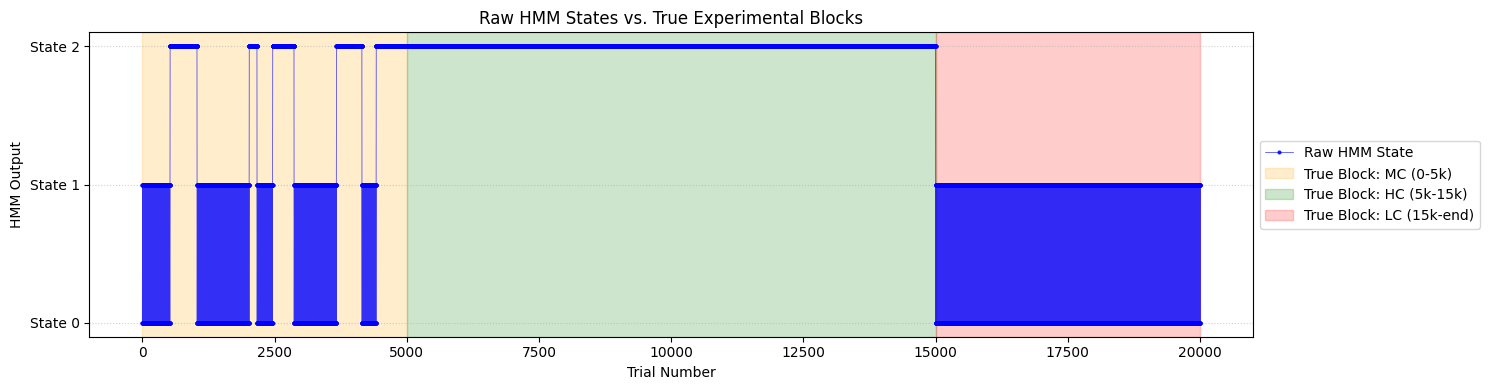

In [35]:
import matplotlib.pyplot as plt

# 1. Create the figure
plt.figure(figsize=(15, 4))

# 2. Plot the raw HMM states directly (they are already integers 0, 1, 2)
# We use markersize=2 and a slight transparency (alpha) to keep it clean
plt.plot(df3.index, df3['hmm_state'], label='Raw HMM State', color='blue', 
         marker='o', markersize=2, linestyle='-', linewidth=0.5, alpha=0.8)

# 3. Add background shading for the True Experimental Blocks
# axvspan shades a vertical region from trial X to trial Y
plt.axvspan(0, 5000, color='orange', alpha=0.2, label='True Block: MC (0-5k)')
plt.axvspan(5000, 15000, color='green', alpha=0.2, label='True Block: HC (5k-15k)')
plt.axvspan(15000, df3.index.max(), color='red', alpha=0.2, label='True Block: LC (15k-end)')

# 4. Format the Y-axis using the knowledge we gained from the crosstab
plt.yticks(ticks=[0, 1, 2], labels=['State 0', 'State 1', 'State 2'])
plt.ylabel('HMM Output')

# 5. Format the X-axis and Title
plt.xlabel('Trial Number')
plt.title('Raw HMM States vs. True Experimental Blocks')
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 6. Format the legend to sit nicely outside the plot area so it doesn't cover your data
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# map hmm states to block labels based on what we observed
# state_to_block = [0: 'LC', 1: 'LC', 2: 'HC']
## Categorical hmm: 3 hidden states, observations(agent_choice, agent_reward)
- Perfect classification of HC1 and HC2 from the rest

- States 0 and 1 (low and medium conflicts), couldnt be separated from each other.
- Both have emission probability being the highest for GW.

- Since MC and LC differ only in proportion of PC vs PI trials. Their average reward patterns are too similar ot distinsguih with choice reward alone

- Raw behavior can easily separate HC and LC/MC.

- So we are adding cue valence information into our HMM.


In [2]:
import pandas as pd
from hmmlearn import hmm

# 1. Map the True Blocks
block_to_label = {
    'B1_MC':  'MC',
    'B2_HC1': 'HC',
    'B3_HC2': 'HC',
    'B4_LC':  'LC'
}
df3['true_label'] = df3['Block'].map(block_to_label)

# 2. Fit the model
model_final = hmm.CategoricalHMM(n_components=3, n_iter=200, random_state=7)
model_final.fit(obs_seq3)

# 3. Decode to raw states (0, 1, or 2)
df3['hmm_state'] = model_final.predict(obs_seq3)

# 4. Print Results using raw states
print("--- Transition matrix ---")
print(pd.DataFrame(
    model_final.transmat_.round(3),
    index=['State 0', 'State 1', 'State 2'],
    columns=['State 0', 'State 1', 'State 2']
))

print("\n--- Emission probabilities ---")
print(pd.DataFrame(
    model_final.emissionprob_.round(3),
    index=['State 0', 'State 1', 'State 2'],
    columns=list(obs_map3.keys())
))

print("\n--- True Block vs Raw HMM State ---")
print(pd.crosstab(
    df3['true_label'], 
    df3['hmm_state'], 
    rownames=['True Block'], 
    colnames=['HMM State']
))

NameError: name 'df3' is not defined

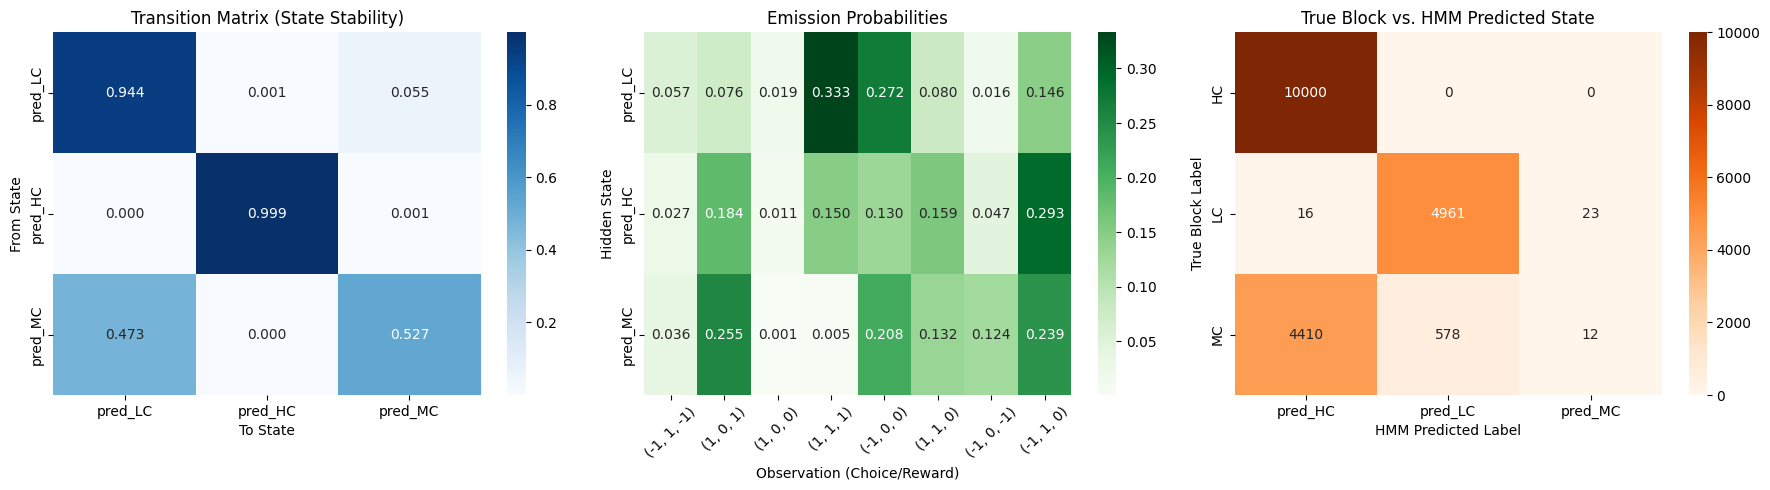

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the dataframes for plotting
trans_df = pd.DataFrame(
    model_final.transmat_,
    index=['pred_LC', 'pred_HC', 'pred_MC'],
    columns=['pred_LC', 'pred_HC', 'pred_MC']
)

emis_df = pd.DataFrame(
    model_final.emissionprob_,
    index=['pred_LC', 'pred_HC', 'pred_MC'],
    # Convert tuples to strings if they aren't already, so they plot cleanly
    columns=[str(k) for k in obs_map3.keys()] 
)

crosstab_df = pd.crosstab(df3['true_label'], df3['hmm_label'])

# 2. Set up a 1x3 grid for the heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot A: Transition Matrix ---
sns.heatmap(trans_df, annot=True, cmap='Blues', fmt='.3f', ax=axes[0])
axes[0].set_title('Transition Matrix (State Stability)')
axes[0].set_xlabel('To State')
axes[0].set_ylabel('From State')

# --- Plot B: Emission Probabilities ---
sns.heatmap(emis_df, annot=True, cmap='Greens', fmt='.3f', ax=axes[1])
axes[1].set_title('Emission Probabilities')
axes[1].set_xlabel('Observation (Choice/Reward)')
axes[1].set_ylabel('Hidden State')
# Rotate x-axis labels if the tuples overlap
axes[1].tick_params(axis='x', rotation=45) 

# --- Plot C: True Block vs. Predicted State (Crosstab) ---
# Note: fmt='d' is used here to display integers instead of decimals for trial counts
sns.heatmap(crosstab_df, annot=True, cmap='Oranges', fmt='d', ax=axes[2])
axes[2].set_title('True Block vs. HMM Predicted State')
axes[2].set_xlabel('HMM Predicted Label')
axes[2].set_ylabel('True Block Label')

# 3. Adjust layout and display
plt.tight_layout()
plt.show()

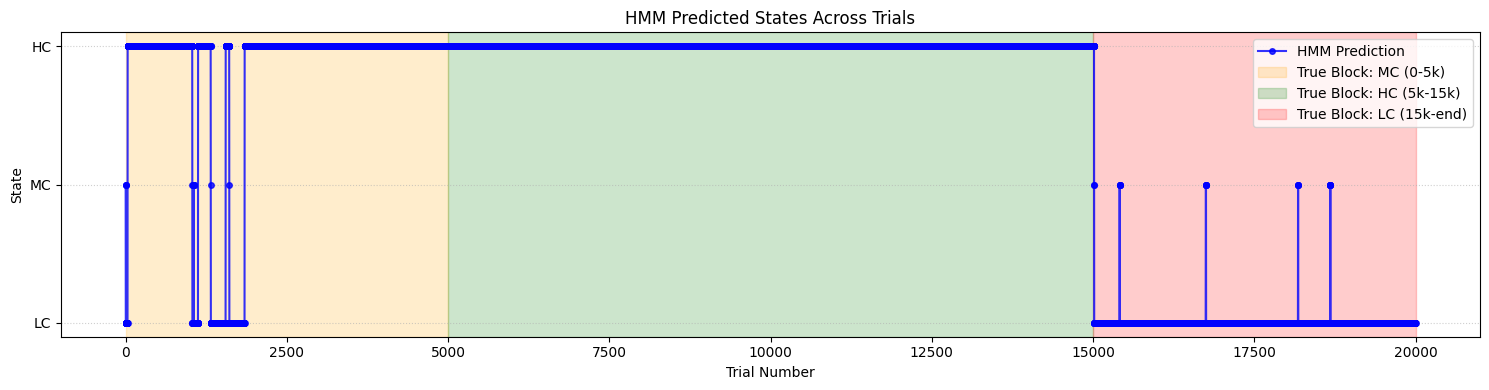

In [91]:
import matplotlib.pyplot as plt

# 1. Clean the HMM labels to match the true labels (remove 'pred_')
df3['clean_hmm_label'] = df3['hmm_label'].str.replace('pred_', '')

# Map both prediction and true labels to these numeric values
y_pred = df3['clean_hmm_label'].map(y_mapping)
y_true = df3['true_label'].map(y_mapping)

# 3. Create the figure
plt.figure(figsize=(15, 4))

# Plot the HMM predictions using a step or line plot
plt.plot(df3.index, y_pred, label='HMM Prediction', color='blue', 
         marker='o', markersize=4, linestyle='-', alpha=0.8)

# Optional: Plot the true labels behind it for visual comparison
# plt.plot(df3.index, y_true, label='True Label', color='red', 
#          marker='', linestyle='--', alpha=0.4, linewidth=2)
plt.axvspan(0, 5000, color='orange', alpha=0.2, label='True Block: MC (0-5k)')
plt.axvspan(5000, 15000, color='green', alpha=0.2, label='True Block: HC (5k-15k)')
plt.axvspan(15000, df3.index.max(), color='red', alpha=0.2, label='True Block: LC (15k-end)')

# 4. Format the Y-axis to show the categorical labels
plt.yticks(ticks=[0, 1, 2], labels=['LC', 'MC', 'HC'])
plt.ylabel('State')

# 5. Format the X-axis and Title
plt.xlabel('Trial Number')
plt.title('HMM Predicted States Across Trials')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [95]:
import itertools
import pandas as pd
from hmmlearn import hmm

# 1. Define the possible values for your 3 tuple positions
var_1 = [-1, 1]       # Cue_Valence
var_2 = [0, 1]        # Agent_Choice
var_3 = [-1, 0, 1]    # Agent_Reward

# 2. Automatically generate all 12 possible combinations
all_combinations = list(itertools.product(var_1, var_2, var_3))

# 3. Create the definitive 12-item dictionary mapping to integers 0-11
obs_map3 = {combo: i for i, combo in enumerate(all_combinations)}

# 4. Zip the actual columns together to create the tuple column
df3['raw_tuples'] = list(zip(df3['Cue_Valence'], df3['Agent_Choice'], df3['Agent_Reward']))

# 5. Map the dataframe using the full 12-item dictionary
df3['obs'] = df3['raw_tuples'].map(obs_map3)

# 6. Extract the sequence for the HMM
obs_seq3 = df3['obs'].values.reshape(-1, 1)

# 7. Fit the HMM
# We explicitly define the labels list to ensure the output is ordered logically
model_final = hmm.CategoricalHMM(n_components=3, n_iter=200, random_state=7)
model_final.fit(obs_seq3)

# 8. Print the full 12-column Emission Probabilities Matrix
# Create a list of string representations for the tuples to use as column names
emission_cols = [str(combo) for combo in all_combinations]

# Check if the model actually built all 12 columns (based on max int seen in data)
n_features_seen = model_final.emissionprob_.shape[1]

print("\n--- Full Emission Probabilities ---")
print(pd.DataFrame(
    model_final.emissionprob_.round(3),
    index=['State 0', 'State 1', 'State 2'],
    # Only assign column names up to the number of features the model actually built
    columns=emission_cols[:n_features_seen] 
))


--- Full Emission Probabilities ---
         (-1, 0, -1)  (-1, 0, 0)  (-1, 0, 1)  (-1, 1, -1)  (-1, 1, 0)  \
State 0        0.017       0.277         0.0        0.059       0.145   
State 1        0.047       0.128         0.0        0.027       0.295   
State 2        0.077       0.185         0.0        0.036       0.229   

         (-1, 1, 1)  (1, 0, -1)  (1, 0, 0)  (1, 0, 1)  (1, 1, -1)  (1, 1, 0)  \
State 0         0.0         0.0      0.021      0.079         0.0      0.076   
State 1         0.0         0.0      0.011      0.185         0.0      0.160   
State 2         0.0         0.0      0.000      0.178         0.0      0.138   

         (1, 1, 1)  
State 0      0.326  
State 1      0.147  
State 2      0.156  
